<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter05/04-迁移学习微调训练-torchkeras版.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 迁移学习微调训练图像分类模型

在自己的图像分类数据集上，使用ImageNet预训练图像分类模型初始化，改动分类层，迁移学习微调训练

同济子豪兄：https://space.bilibili.com/1900783

[代码运行云GPU环境](https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1)：GPU RTX 3060、CUDA v11.2

## 导入工具包

In [1]:
import time
import os

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline

# 忽略烦人的红色提示
import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体
plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号


## 获取计算硬件

In [2]:
# 有 GPU 就用 GPU，没有就用 CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device', device)

device cuda:0


## 图像预处理

In [3]:
from torchvision import transforms

# 训练集图像预处理：缩放裁剪、图像增强、转 Tensor、归一化
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                     ])

# 测试集图像预处理-RCTN：缩放、裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(256),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
                                    ])

## 载入图像分类数据集

In [4]:
# 数据集文件夹路径
dataset_dir = '../datasets/fruit30_split'
train_path = os.path.join(dataset_dir, 'train')
test_path = os.path.join(dataset_dir, 'val')
print('训练集路径', train_path)
print('测试集路径', test_path)

训练集路径 ../datasets/fruit30_split/train
测试集路径 ../datasets/fruit30_split/val


In [5]:
from torchvision import datasets

# 载入训练集
train_dataset = datasets.ImageFolder(train_path, train_transform)

# 载入测试集
test_dataset = datasets.ImageFolder(test_path, test_transform)

In [6]:
print('训练集图像数量', len(train_dataset))
print('类别个数', len(train_dataset.classes))
print('各类别名称', train_dataset.classes)

训练集图像数量 4375
类别个数 30
各类别名称 ['哈密瓜', '圣女果', '山竹', '杨梅', '柚子', '柠檬', '桂圆', '梨', '椰子', '榴莲', '火龙果', '猕猴桃', '石榴', '砂糖橘', '胡萝卜', '脐橙', '芒果', '苦瓜', '苹果-红', '苹果-青', '草莓', '荔枝', '菠萝', '葡萄-白', '葡萄-红', '西瓜', '西红柿', '车厘子', '香蕉', '黄瓜']


In [7]:
print('测试集图像数量', len(test_dataset))
print('类别个数', len(test_dataset.classes))
print('各类别名称', test_dataset.classes)

测试集图像数量 1078
类别个数 30
各类别名称 ['哈密瓜', '圣女果', '山竹', '杨梅', '柚子', '柠檬', '桂圆', '梨', '椰子', '榴莲', '火龙果', '猕猴桃', '石榴', '砂糖橘', '胡萝卜', '脐橙', '芒果', '苦瓜', '苹果-红', '苹果-青', '草莓', '荔枝', '菠萝', '葡萄-白', '葡萄-红', '西瓜', '西红柿', '车厘子', '香蕉', '黄瓜']


## 类别和索引号 一一对应

In [8]:
# 各类别名称
class_names = train_dataset.classes
n_class = len(class_names)
print(n_class)

30


In [9]:
class_names

['哈密瓜',
 '圣女果',
 '山竹',
 '杨梅',
 '柚子',
 '柠檬',
 '桂圆',
 '梨',
 '椰子',
 '榴莲',
 '火龙果',
 '猕猴桃',
 '石榴',
 '砂糖橘',
 '胡萝卜',
 '脐橙',
 '芒果',
 '苦瓜',
 '苹果-红',
 '苹果-青',
 '草莓',
 '荔枝',
 '菠萝',
 '葡萄-白',
 '葡萄-红',
 '西瓜',
 '西红柿',
 '车厘子',
 '香蕉',
 '黄瓜']

In [10]:
# 映射关系：类别 到 索引号
train_dataset.class_to_idx

{'哈密瓜': 0,
 '圣女果': 1,
 '山竹': 2,
 '杨梅': 3,
 '柚子': 4,
 '柠檬': 5,
 '桂圆': 6,
 '梨': 7,
 '椰子': 8,
 '榴莲': 9,
 '火龙果': 10,
 '猕猴桃': 11,
 '石榴': 12,
 '砂糖橘': 13,
 '胡萝卜': 14,
 '脐橙': 15,
 '芒果': 16,
 '苦瓜': 17,
 '苹果-红': 18,
 '苹果-青': 19,
 '草莓': 20,
 '荔枝': 21,
 '菠萝': 22,
 '葡萄-白': 23,
 '葡萄-红': 24,
 '西瓜': 25,
 '西红柿': 26,
 '车厘子': 27,
 '香蕉': 28,
 '黄瓜': 29}

In [11]:
# 映射关系：索引号 到 类别
idx_to_labels = {y:x for x,y in train_dataset.class_to_idx.items()}

In [12]:
idx_to_labels

{0: '哈密瓜',
 1: '圣女果',
 2: '山竹',
 3: '杨梅',
 4: '柚子',
 5: '柠檬',
 6: '桂圆',
 7: '梨',
 8: '椰子',
 9: '榴莲',
 10: '火龙果',
 11: '猕猴桃',
 12: '石榴',
 13: '砂糖橘',
 14: '胡萝卜',
 15: '脐橙',
 16: '芒果',
 17: '苦瓜',
 18: '苹果-红',
 19: '苹果-青',
 20: '草莓',
 21: '荔枝',
 22: '菠萝',
 23: '葡萄-白',
 24: '葡萄-红',
 25: '西瓜',
 26: '西红柿',
 27: '车厘子',
 28: '香蕉',
 29: '黄瓜'}

In [13]:
# 保存为本地的 npy 文件
np.save('idx_to_labels.npy', idx_to_labels)
np.save('labels_to_idx.npy', train_dataset.class_to_idx)

## 定义数据加载器DataLoader

In [14]:
from torch.utils.data import DataLoader

In [15]:
BATCH_SIZE = 32

# 训练集的数据加载器
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=4
                         )

# 测试集的数据加载器
test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False,
                         num_workers=4
                        )

## 查看一个batch的图像和标注

In [16]:
# DataLoader 是 python生成器，每次调用返回一个 batch 的数据
images, labels = next(iter(train_loader))

In [17]:
images.shape

torch.Size([32, 3, 224, 224])

In [18]:
labels

tensor([15, 19, 29,  1,  5, 28,  4, 28, 10, 19, 27, 11, 23, 21, 10,  2, 13, 23,
        13,  0, 13,  3,  4,  0, 10, 21, 19,  1,  2,  6,  5,  2])

## 可视化一个batch的图像和标注

In [19]:
# 将数据集中的Tensor张量转为numpy的array数据类型
images = images.numpy()

In [20]:
images[5].shape

(3, 224, 224)

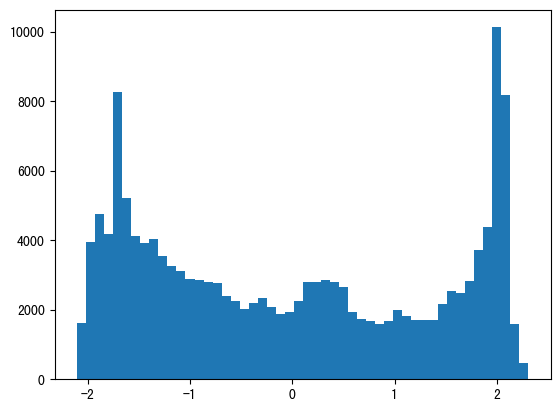

In [21]:
plt.hist(images[5].flatten(), bins=50)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.64].


Text(0.5, 1.0, 'label:29')

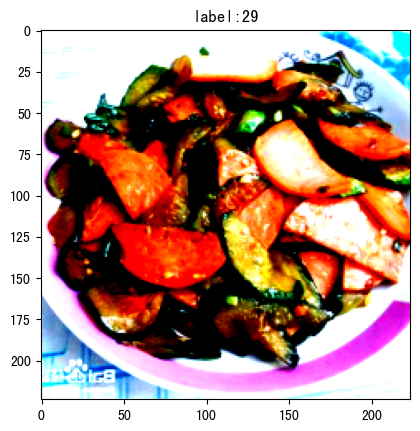

In [22]:
# batch 中经过预处理的图像
idx = 2
plt.imshow(images[idx].transpose((1,2,0))) # 转为(224, 224, 3)
plt.title('label:'+str(labels[idx].item()))

In [23]:
label = labels[idx].item()

In [24]:
label

29

In [25]:
pred_classname = idx_to_labels[label]

In [26]:
pred_classname

'黄瓜'

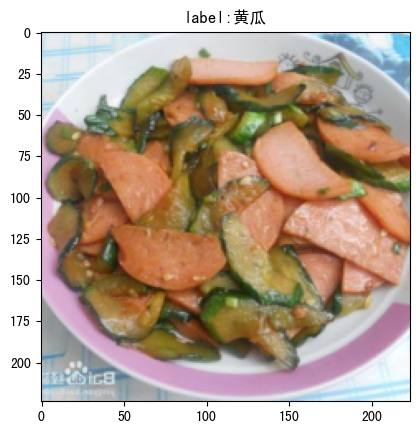

In [27]:
# 原始图像
idx = 2
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
plt.imshow(np.clip(images[idx].transpose((1,2,0)) * std + mean, 0, 1))
plt.title('label:'+ pred_classname)
plt.show()

## 导入训练需使用的工具包

In [39]:
from torchvision import models
import torch.optim as optim
from torch.optim import lr_scheduler
import torchkeras
import torchmetrics

## 选择迁移学习训练方式

斯坦福CS231N【迁移学习】中文精讲：https://www.bilibili.com/video/BV1K7411W7So

斯坦福CS231N【迁移学习】官方笔记：https://cs231n.github.io/transfer-learning

ResNet算法精讲与论文逐句精读：https://www.bilibili.com/video/BV1vb4y1k7BV

### 选择一：只微调训练模型最后一层（全连接分类层）

<<<<<< ⚡️ cuda is used >>>>>>


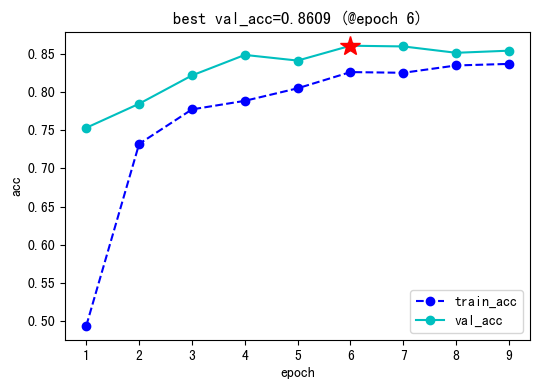

<<<<<< val_acc without improvement in 3 epoch,early stopping >>>>>> 



In [59]:

# 载入预训练模型
resnet1 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 1. 查看模型各层名称和是否需要梯度
# for name, param in resnet1.named_parameters():
#     if param.requires_grad:
#         print(name)

# 2. 修改全连接层，使得全连接层的输出与当前数据集类别数对应
# 新建的层默认 requires_grad=True
resnet1.fc = nn.Linear(resnet1.fc.in_features, n_class)

# 3. 只微调训练最后一层全连接层的参数，其它层冻结
for param in resnet1.parameters():
    param.requires_grad = False
# 只微调最后一层全连接层的参数
for param in resnet1.fc.parameters():
    param.requires_grad = True

# 4. 定义损失函数、优化器和学习率调度器
criterion1 = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(resnet1.fc.parameters(), lr=0.001)  # 只优化最后一层
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.1)

# 5. 使用 torchkeras 构建训练框架
model1 = torchkeras.KerasModel(net=resnet1,loss_fn=criterion1,
                               metrics_dict={"acc": torchmetrics.Accuracy(task="multiclass", num_classes=n_class),
                                             "f1": torchmetrics.F1Score(task="multiclass", num_classes=n_class)},
                               optimizer=optimizer1)

# 6. 训练模型
history1 = model1.fit(train_data=train_loader, 
                    val_data=test_loader, 
                    epochs=20, 
                    ckpt_path='resnet1_finetune.pth', 
                    patience=3,
                    monitor="val_acc",
                    mode="max",
                    plot=True
)

In [60]:
type(history1)
history1

,epoch,train_loss,train_acc,train_f1,lr,val_loss,val_acc,val_f1
0,1,2.119753,0.493714,0.493714,0.001,1.073781,0.753247,0.753247
1,2,1.096206,0.732114,0.732114,0.001,0.770978,0.784787,0.784787
2,3,0.847204,0.777371,0.777371,0.001,0.627970,0.821892,0.821892
3,4,0.762559,0.788571,0.788571,0.001,0.559056,0.848794,0.848794
4,5,0.677279,0.805029,0.805029,0.001,0.528021,0.841373,0.841373
5,6,0.619991,0.826286,0.826286,0.001,0.500214,0.860853,0.860853
6,7,0.589594,0.825371,0.825371,0.001,0.466717,0.859926,0.859926
7,8,0.563349,0.834971,0.834971,0.001,0.473506,0.851577,0.851577
8,9,0.557480,0.837029,0.837029,0.001,0.468123,0.854360,0.854360


### 选择二：微调训练所有层

<<<<<< ⚡️ cuda is used >>>>>>


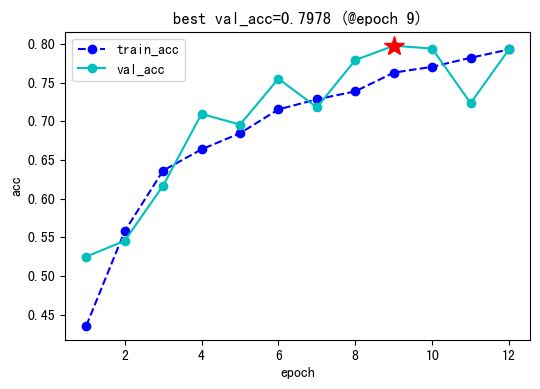

<<<<<< val_acc without improvement in 3 epoch,early stopping >>>>>> 



In [58]:

# 载入预训练模型
resnet2 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. 修改全连接层，使得全连接层的输出与当前数据集类别数对应
# 新建的层默认 requires_grad=True
resnet2.fc = nn.Linear(resnet2.fc.in_features, n_class)


# 4. 定义损失函数、优化器和学习率调度器
criterion2 = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(resnet2.parameters(), lr=0.001) #优化所有层
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=0.1)

# 5. 使用 torchkeras 构建训练框架
model2 = torchkeras.KerasModel(net=resnet2,loss_fn=criterion2,
                               metrics_dict={"acc": torchmetrics.Accuracy(task="multiclass", num_classes=n_class),
                                             "f1": torchmetrics.F1Score(task="multiclass", num_classes=n_class)},
                               optimizer=optimizer2)

# 6. 训练模型
history2 = model2.fit(train_data=train_loader, 
                    val_data=test_loader, 
                    epochs=20, 
                    ckpt_path='resnet2_finetune.pth', 
                    patience=3,
                    monitor="val_acc",
                    mode="max",
                    plot=True
)



### 选择三：随机初始化模型全部权重，从头训练所有层

<<<<<< ⚡️ cuda is used >>>>>>


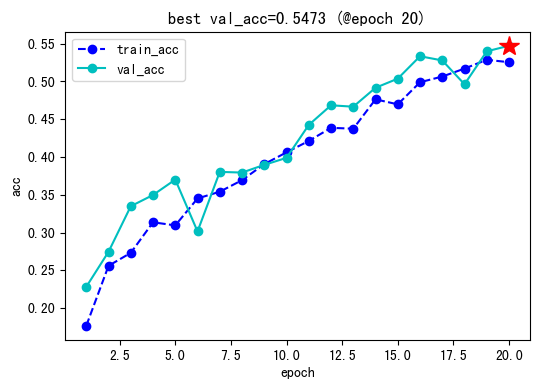

In [62]:
# 载入预训练模型
resnet3 = models.resnet18()

# 2. 修改全连接层，使得全连接层的输出与当前数据集类别数对应
# 新建的层默认 requires_grad=True
resnet3.fc = nn.Linear(resnet3.fc.in_features, n_class)


# 4. 定义损失函数、优化器和学习率调度器
criterion3 = nn.CrossEntropyLoss()
optimizer3 = optim.Adam(resnet3.parameters(), lr=0.001) #优化所有层
scheduler3 = optim.lr_scheduler.StepLR(optimizer3, step_size=10, gamma=0.1)

# 5. 使用 torchkeras 构建训练框架
model3 = torchkeras.KerasModel(net=resnet3,loss_fn=criterion3,
                               metrics_dict={"acc": torchmetrics.Accuracy(task="multiclass", num_classes=n_class),
                                             "f1": torchmetrics.F1Score(task="multiclass", num_classes=n_class)},
                               optimizer=optimizer3)

# 6. 训练模型
history3 = model3.fit(train_data=train_loader, 
                    val_data=test_loader, 
                    epochs=20, 
                    ckpt_path='resnet3_finetune.pth', 
                    patience=3,
                    monitor="val_acc",
                    mode="max",
                    plot=True
)


In [63]:
history3

,epoch,train_loss,train_acc,train_f1,lr,val_loss,val_acc,val_f1
0,1,2.784569,0.176686,0.176686,0.001,2.494788,0.228200,0.228200
1,2,2.406552,0.256000,0.256000,0.001,2.394140,0.274583,0.274583
2,3,2.330400,0.273143,0.273143,0.001,2.159848,0.334879,0.334879
3,4,2.236063,0.313600,0.313600,0.001,2.106072,0.349722,0.349722
4,5,2.224799,0.309486,0.309486,0.001,2.082717,0.370130,0.370130
5,6,2.090285,0.345143,0.345143,0.001,2.235312,0.301484,0.301484
6,7,2.045249,0.354057,0.354057,0.001,2.015290,0.380334,0.380334
7,8,2.031156,0.369371,0.369371,0.001,1.968562,0.379406,0.379406
8,9,1.959311,0.390629,0.390629,0.001,1.988071,0.389610,0.389610
9,10,1.898251,0.406171,0.406171,0.001,1.876853,0.398887,0.398887


In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline



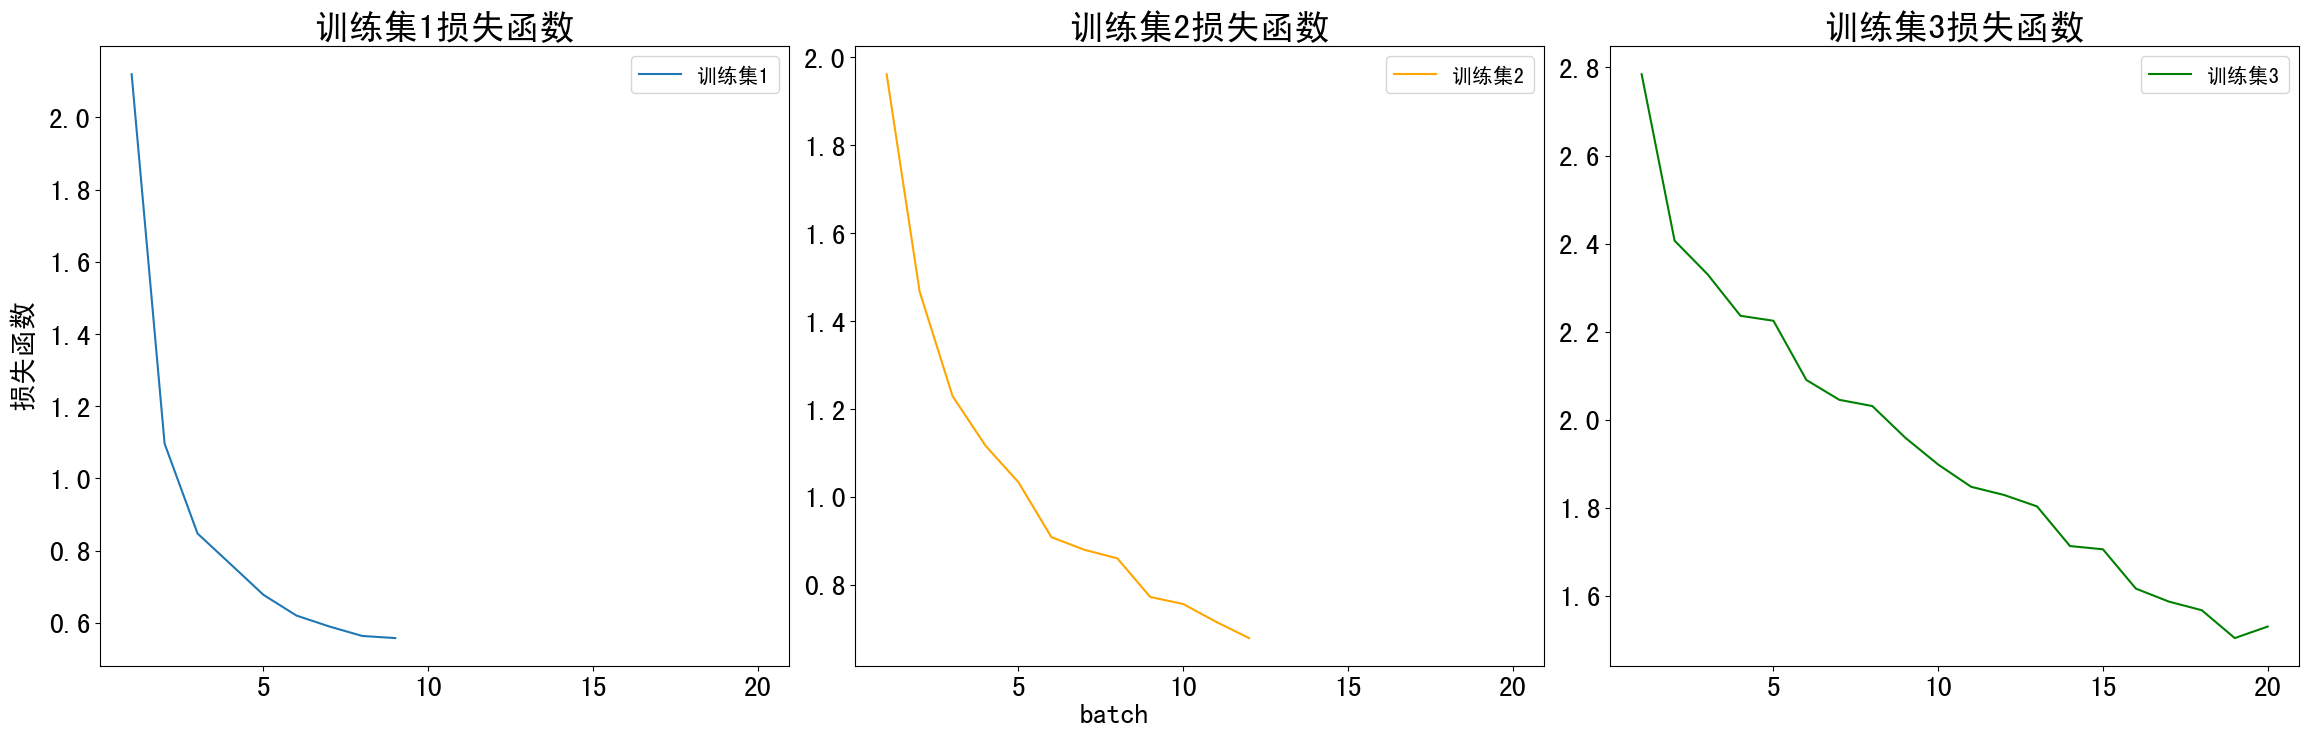

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharex=True)

# Plotting history in the first subplot
axs[0].plot(history1['epoch'], history1['train_loss'], label='训练集1')
axs[0].set_title('训练集1损失函数', fontsize=25)
axs[0].tick_params(labelsize=20)
axs[0].legend(fontsize=15)

# Plotting df_train2 in the second subplot
axs[1].plot(history2['epoch'], history2['train_loss'], color='orange', label='训练集2')
axs[1].set_title('训练集2损失函数', fontsize=25)
axs[1].tick_params(labelsize=20)
axs[1].legend(fontsize=15)

# Plotting df_train3 in the third subplot
axs[2].plot(history3['epoch'], history3['train_loss'], color='green', label='训练集3')
axs[2].set_title('训练集3损失函数', fontsize=25)
axs[2].tick_params(labelsize=20)
axs[2].legend(fontsize=15)

# Setting common labels
fig.text(0.5, 0.04, 'batch', ha='center', fontsize=20) # x-axis label shared by all subplots
fig.text(0.04, 0.5, '损失函数', va='center', rotation='vertical', fontsize=20) # y-axis label shared by all subplots

# Adjusting layout to prevent overlap
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# Saving the figure with a new filename to avoid overwriting
# plt.savefig('多个训练集的损失函数_subplots.pdf', dpi=120, bbox_inches='tight')

plt.show()

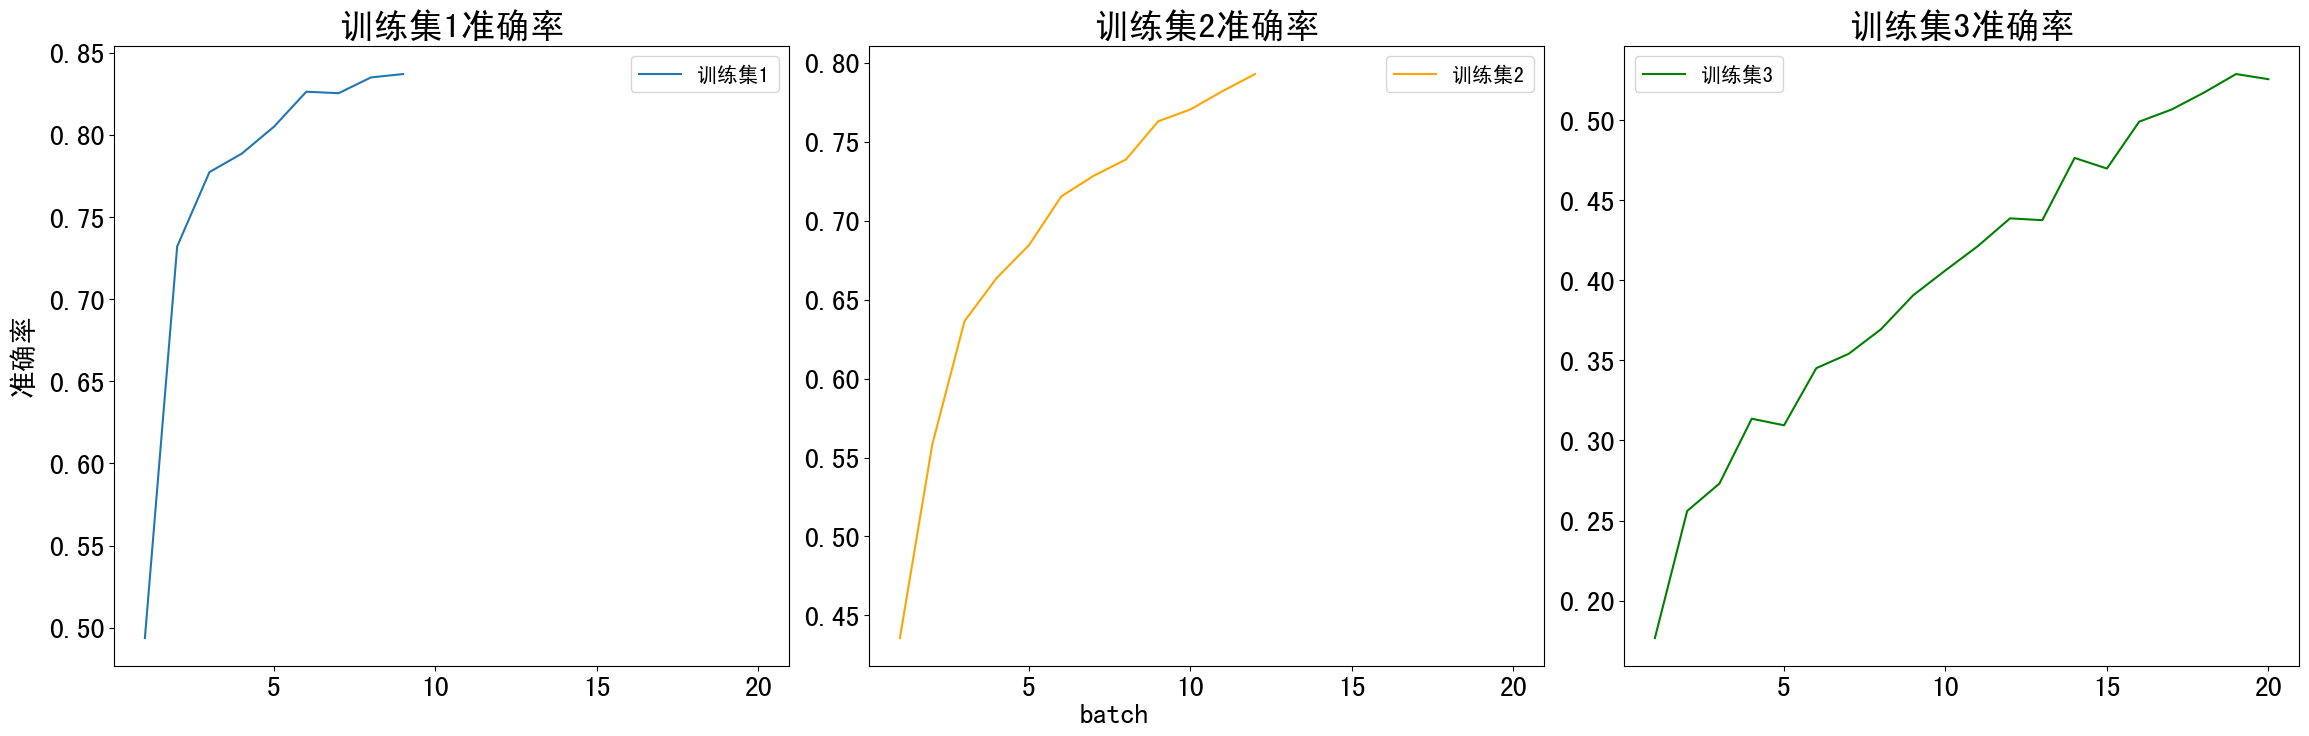

In [65]:
fig, axs = plt.subplots(1, 3, figsize=(24, 8), sharex=True)

# Plotting df_train1 in the first subplot
axs[0].plot(history1['epoch'], history1['train_acc'], label='训练集1')
axs[0].set_title('训练集1准确率', fontsize=25)
axs[0].tick_params(labelsize=20)
axs[0].legend(fontsize=15)

# Plotting df_train2 in the second subplot
axs[1].plot(history2['epoch'], history2['train_acc'], color='orange', label='训练集2')
axs[1].set_title('训练集2准确率', fontsize=25)
axs[1].tick_params(labelsize=20)
axs[1].legend(fontsize=15)

# Plotting df_train3 in the third subplot
axs[2].plot(history3['epoch'], history3['train_acc'], color='green', label='训练集3')
axs[2].set_title('训练集3准确率', fontsize=25)
axs[2].tick_params(labelsize=20)
axs[2].legend(fontsize=15)

# Setting common labels
fig.text(0.5, 0.04, 'batch', ha='center', fontsize=20) # x-axis label shared by all subplots
fig.text(0.04, 0.5, '准确率', va='center', rotation='vertical', fontsize=20) # y-axis label shared by all subplots

# Adjusting layout to prevent overlap
plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

# Saving the figure with a new filename to avoid overwriting
# plt.savefig('多个训练集的准确率_subplots.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 参考文档

https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

https://www.bilibili.com/video/BV1qe4y1D7zD

https://www.bilibili.com/video/BV14J411X7Bb

https://www.bilibili.com/video/BV1w4411u7ay